In [1]:
# =============================================================================
# CELDA 1 — IMPORTS
# =============================================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from imblearn.over_sampling import SMOTE
 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
 
keras.utils.set_random_seed(42)   # semillas fijas para reproducibilidad

print("TensorFlow:", tf.__version__)
print("Librerías cargadas.")

TensorFlow: 2.21.0
Librerías cargadas.


In [2]:
# =============================================================================
# CELDA 2 — CARGAMOS Y MOSTRAMOS EL DATASET
# =============================================================================

df = sns.load_dataset('titanic')
 
print("Forma:", df.shape)
print("\nValores faltantes:\n", df.isnull().sum())
print("\nDistribución de clases:\n", df['survived'].value_counts())

Forma: (891, 15)

Valores faltantes:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Distribución de clases:
 survived
0    549
1    342
Name: count, dtype: int64


In [3]:
# ----------------------------------------------------------------------------------------
# CELDA 3 — PREPROCESAMIENTO DE DATOS - LIMPIEZA Y CODIFICACIÓN DE VARIABLES CATEGORICAS
# ----------------------------------------------------------------------------------------
# Seleccionamos solo las columnas útiles para predecir supervivencia.
# Eliminamos: name, ticket, cabin, class, who, adult_male, embark_town, alive, alone
#   (redundantes o irrelevantes; 'alive' es la única con fuga directa: es la variable objetivo)

columnas = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df[columnas].dropna(subset=['embarked']).copy()      # eliminamos 2 filas con NaN en embarked

df['sex'] = (df['sex'] == 'male').astype(int)             # female=0, male=1
df = pd.get_dummies(df, columns=['embarked'],             # one-hot: embarked_Q, embarked_S
                    drop_first=True, dtype=int)           # (C es la categoría base; no hay orden falso)

# OJO: 'age' todavía tiene valores faltantes. Se imputa con la mediana del TRAIN
# dentro de cada fold (celda 6) para no filtrar información del test.
print("Dataset limpio:", df.shape)
print(df.isnull().sum())

Dataset limpio: (889, 9)
survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked_Q      0
embarked_S      0
dtype: int64


In [4]:
# -----------------------------------------------------------------------------
# CELDA 4 — SEPARACIÓN DE X e y
# -----------------------------------------------------------------------------
# IMPORTANTE: acá NO escalamos ni balanceamos. Ambas operaciones "aprenden" de los datos,
# así que si se hacen antes de la validación cruzada el test se contamina (fuga de datos).
# Se aplican dentro de cada fold, solo con el train (ver celda 6):
#   - StandardScaler: lleva las variables a media=0, desvío=1 (sin esto 'fare' dominaría a 'pclass').
#   - SMOTE: genera ejemplos sintéticos de la clase minoritaria (sobrevivió=1) para igualar clases.

X = df.drop('survived', axis=1).values
y = df['survived'].values

if X.shape[0] == y.shape[0] and 'survived' not in df.drop('survived', axis=1).columns:
    print("X e Y separados correctamente")
else:
    print("Error: X e Y no se han podido separar correctamente")

X e Y separados correctamente


In [5]:
# -----------------------------------------------------------------------------
# CELDA 5 — FUNCION PARA CREAR LOS MODELOS DE REDES NEURONALES
# -----------------------------------------------------------------------------
# Definimos los 3 modelos como función para poder instanciarlos frescos en cada fold de la validación cruzada (sin pesos heredados de iteraciones anteriores).

# Modelo 1: simple (1 capa, ReLU, Adam rápido)     → baseline
# Modelo 2: profundo (2 capas, Tanh, Adam lento)    → mayor capacidad
# Modelo 3: ancho + Dropout (ReLU, SGD con momentum) → regularización

def crear_modelo(tipo, n_features):
    if tipo == 1:
        m = keras.Sequential([
            keras.Input(shape=(n_features,)),
            layers.Dense(16, activation='relu'),
            layers.Dense(1,  activation='sigmoid')
        ], name="Modelo_1")
        m.compile(optimizer=keras.optimizers.Adam(0.01),
                  loss='binary_crossentropy', metrics=['accuracy'])

    elif tipo == 2:
        m = keras.Sequential([
            keras.Input(shape=(n_features,)),
            layers.Dense(32, activation='tanh'),
            layers.Dense(16, activation='tanh'),
            layers.Dense(1,  activation='sigmoid')
        ], name="Modelo_2")
        m.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])

    elif tipo == 3:
        m = keras.Sequential([
            keras.Input(shape=(n_features,)),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(1,  activation='sigmoid')
        ], name="Modelo_3")
        m.compile(optimizer=keras.optimizers.SGD(0.01, momentum=0.9),
                  loss='binary_crossentropy', metrics=['accuracy'])

    return m

In [6]:
# -----------------------------------------------------------------------------
# CELDA 6 — VALIDACIÓN CRUZADA 5-Fold con acumulación de predicciones
# -----------------------------------------------------------------------------
# Entrenamos cada modelo 5 veces con particiones distintas (StratifiedKFold).
# En cada fold acumulamos las predicciones para la matriz de confusión, evitando un segundo ciclo de entrenamiento innecesario.

# Orden correcto dentro de cada fold (todo se ajusta SOLO con el train):
#   1) imputar 'age' con la mediana  2) estandarizar  3) separar validación  4) balancear con datos sinteticos 5) entrenar  6) evaluar en test REAL
# EarlyStopping: detiene el entrenamiento si val_loss no mejora en 10 épocas y restaura los mejores pesos automáticamente.

kfold   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
idx_age = list(df.drop('survived', axis=1).columns).index('age')

resultados_cv = {}   # métricas por fold de cada modelo
predicciones  = {}   # predicciones acumuladas para matrices de confusión

for tipo in [1, 2, 3]:
    nombre   = f"Modelo_{tipo}"
    metricas = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    y_real_total, y_pred_total = [], []

    print(f"\nEntrenando {nombre} — 5-Fold CV...")

    for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y)):
        X_tr, X_te = X[train_idx].copy(), X[test_idx].copy()
        y_tr, y_te = y[train_idx], y[test_idx]

        # 1) Imputar 'age' con la mediana del TRAIN
        mediana = np.nanmedian(X_tr[:, idx_age])
        X_tr[np.isnan(X_tr[:, idx_age]), idx_age] = mediana
        X_te[np.isnan(X_te[:, idx_age]), idx_age] = mediana

        # 2) Estandarizar ajustando solo con el TRAIN
        scaler = StandardScaler().fit(X_tr)
        X_tr, X_te = scaler.transform(X_tr), scaler.transform(X_te)

        # 3) 15% del train como validación para EarlyStopping (antes de SMOTE)
        X_tr, X_vl, y_tr, y_vl = train_test_split(
            X_tr, y_tr, test_size=0.15, stratify=y_tr, random_state=fold)

        # 4) SMOTE solo sobre el train para balancear clases (no sobre validación ni test)
        X_tr, y_tr = SMOTE(random_state=42).fit_resample(X_tr, y_tr)

        # 5) Entrenar (EarlyStopping nuevo en cada fold)
        callback = keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True)
        modelo = crear_modelo(tipo, X.shape[1])
        modelo.fit(X_tr, y_tr, epochs=100, batch_size=32,
                   validation_data=(X_vl, y_vl),
                   callbacks=[callback], verbose=0)

        # 6) Evaluar en el test REAL (sin datos sintéticos)
        y_pred = (modelo.predict(X_te, verbose=0) > 0.5).astype(int).ravel()

        # Métricas del fold
        metricas['accuracy'].append(accuracy_score(y_te, y_pred))
        metricas['precision'].append(precision_score(y_te, y_pred, zero_division=0))
        metricas['recall'].append(recall_score(y_te, y_pred, zero_division=0))
        metricas['f1'].append(f1_score(y_te, y_pred, zero_division=0))

        # Acumulamos para la matriz de confusión
        y_real_total.extend(y_te)
        y_pred_total.extend(y_pred)

        print(f"  Fold {fold+1}/5 — F1: {metricas['f1'][-1]:.4f}")

    resultados_cv[nombre] = metricas
    predicciones[nombre]  = (y_real_total, y_pred_total)

print("\n¡Entrenamiento completado!")


Entrenando Modelo_1 — 5-Fold CV...
  Fold 1/5 — F1: 0.7704
  Fold 2/5 — F1: 0.7299
  Fold 3/5 — F1: 0.7023
  Fold 4/5 — F1: 0.7619
  Fold 5/5 — F1: 0.7413

Entrenando Modelo_2 — 5-Fold CV...
  Fold 1/5 — F1: 0.7586
  Fold 2/5 — F1: 0.7500
  Fold 3/5 — F1: 0.6970
  Fold 4/5 — F1: 0.7917
  Fold 5/5 — F1: 0.7448

Entrenando Modelo_3 — 5-Fold CV...
  Fold 1/5 — F1: 0.7619
  Fold 2/5 — F1: 0.7391
  Fold 3/5 — F1: 0.6615
  Fold 4/5 — F1: 0.7755
  Fold 5/5 — F1: 0.7391

¡Entrenamiento completado!


In [7]:
# -----------------------------------------------------------------------------
# CELDA 7 — Tabla resumen: media ± desvío estándar
# -----------------------------------------------------------------------------
# El desvío estándar indica estabilidad: cuanto más bajo, más consistente es el modelo entre distintas particiones de datos.
 
filas = []
for nombre, m in resultados_cv.items():
    filas.append({
        'Modelo':    nombre,
        'Accuracy':  f"{np.mean(m['accuracy']):.4f} ± {np.std(m['accuracy']):.4f}",
        'Precision': f"{np.mean(m['precision']):.4f} ± {np.std(m['precision']):.4f}",
        'Recall':    f"{np.mean(m['recall']):.4f} ± {np.std(m['recall']):.4f}",
        'F1-Score':  f"{np.mean(m['f1']):.4f} ± {np.std(m['f1']):.4f}",
    })
 
print(pd.DataFrame(filas).to_string(index=False))

  Modelo        Accuracy       Precision          Recall        F1-Score
Modelo_1 0.7986 ± 0.0154 0.7293 ± 0.0251 0.7559 ± 0.0489 0.7412 ± 0.0242
Modelo_2 0.7998 ± 0.0184 0.7190 ± 0.0165 0.7824 ± 0.0553 0.7484 ± 0.0305
Modelo_3 0.7930 ± 0.0211 0.7162 ± 0.0134 0.7588 ± 0.0730 0.7354 ± 0.0395


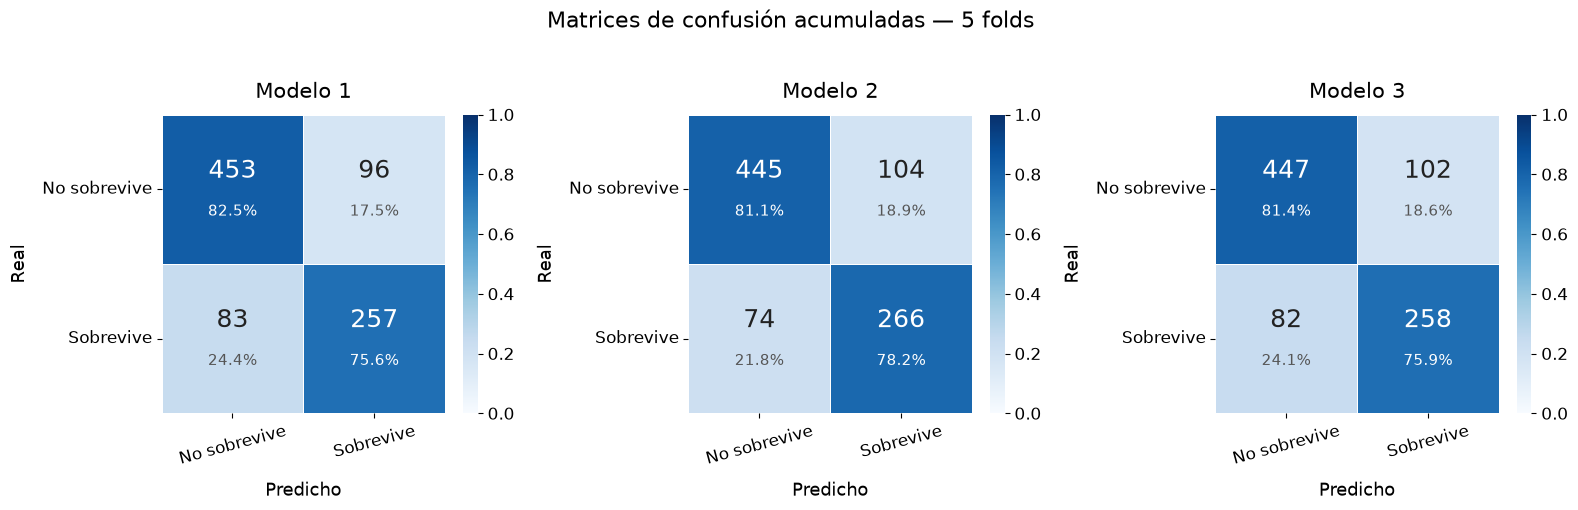

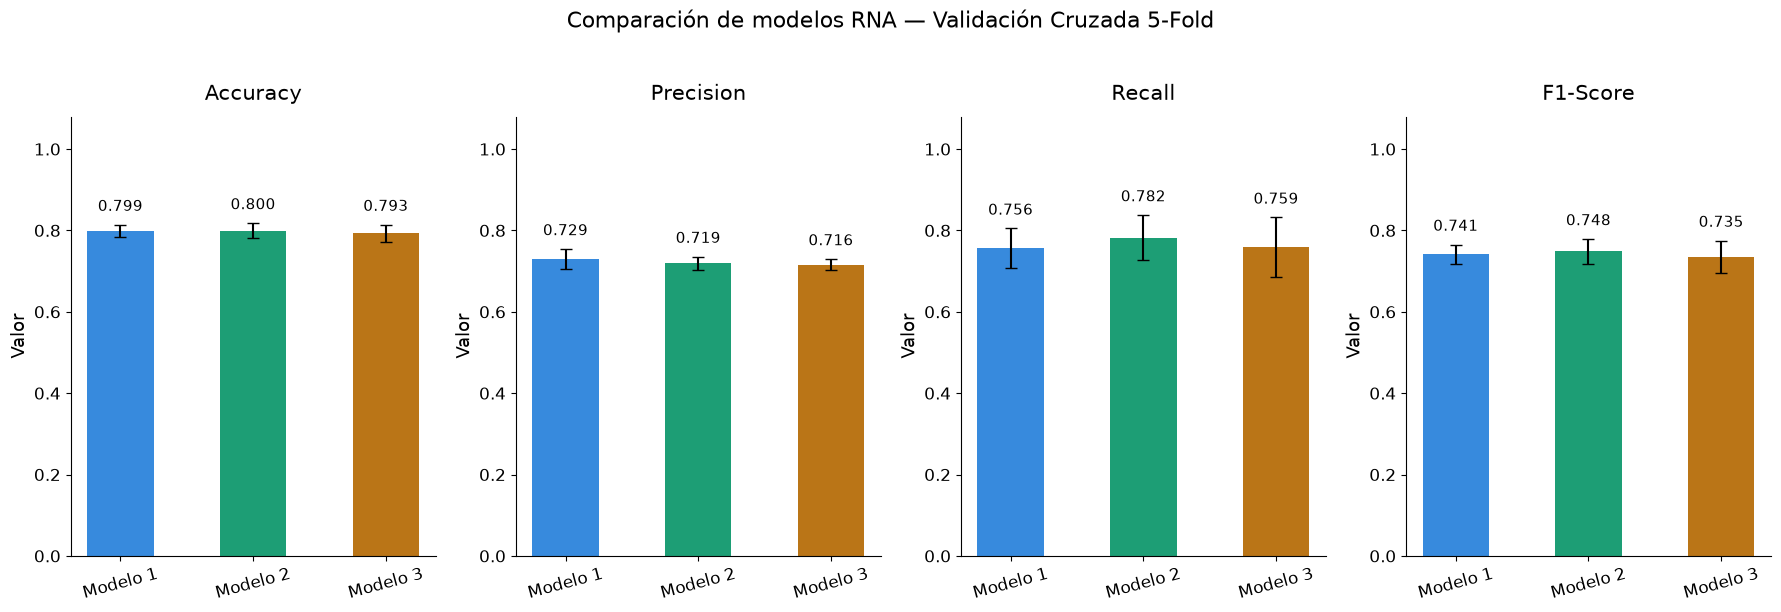

In [8]:
# -----------------------------------------------------------------------------
# CELDA 8 — GRAFICOS
# -----------------------------------------------------------------------------
# Estilo general
plt.rcParams.update({
    'font.size':        13,
    'axes.titlesize':   15,
    'axes.labelsize':   13,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
})

colores = ['#378ADD', '#1D9E75', '#BA7517']
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1']
titulos          = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# --- Figura 1: Matrices de confusión ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Matrices de confusión acumuladas — 5 folds',
             fontsize=16, fontweight='normal', y=1.02)

for ax, tipo in zip(axes, [1, 2, 3]):
    y_real, y_pred = predicciones[f'Modelo_{tipo}']
    cm = confusion_matrix(y_real, y_pred)

    # Normalizamos para mostrar porcentajes
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=False, cmap='Blues',
                ax=ax, vmin=0, vmax=1,
                linewidths=0.5, linecolor='white',
                xticklabels=['No sobrevive', 'Sobrevive'],
                yticklabels=['No sobrevive', 'Sobrevive'])

    # Anotaciones con valor absoluto y porcentaje
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.38,
                    f'{cm[i, j]}',
                    ha='center', va='center',
                    fontsize=18, fontweight='normal',
                    color='white' if cm_norm[i, j] > 0.5 else '#222')
            ax.text(j + 0.5, i + 0.65,
                    f'{cm_norm[i, j]:.1%}',
                    ha='center', va='center',
                    fontsize=11,
                    color='white' if cm_norm[i, j] > 0.5 else '#555')

    ax.set_title(f'Modelo {tipo}', pad=12)
    ax.set_xlabel('Predicho', labelpad=10)
    ax.set_ylabel('Real', labelpad=10)
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figura 2: Gráfico comparativo ---
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Comparación de modelos RNA — Validación Cruzada 5-Fold',
             fontsize=16, fontweight='normal', y=1.02)

for ax, metrica, titulo in zip(axes, metricas_nombres, titulos):
    medias = [np.mean(resultados_cv[f'Modelo_{i}'][metrica]) for i in [1,2,3]]
    stds   = [np.std(resultados_cv[f'Modelo_{i}'][metrica])  for i in [1,2,3]]

    bars = ax.bar(['Modelo 1', 'Modelo 2', 'Modelo 3'],
              medias,
              yerr=stds, capsize=4, color=colores, width=0.5)

    ax.set_title(titulo, pad=12)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('Valor')
    ax.grid(False)
    ax.tick_params(axis='x', rotation=15)

    for bar, media, std in zip(bars, medias, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 0.025,
                f'{media:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='normal')

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()